In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


df_player_stats = pd.read_csv("./player_stats/2023-2024_NBA_Player Stats_Regular.csv",
                  sep=";",
    encoding="cp1252")
df_betting = pd.read_csv("./betting/nba_2008-2025.csv")
df_games = pd.read_csv("./games_new/teams_game_2023-24.csv")

# Cleaning player stats data

In [3]:
df_player_stats.shape

(735, 30)

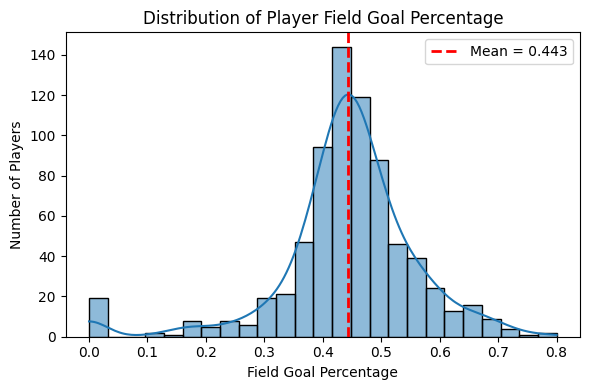

In [4]:

plt.figure(figsize=(6,4))

sns.histplot(
    df_player_stats["FG%"],
    bins=25,
    kde=True
)

plt.axvline(
    df_player_stats["FG%"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df_player_stats['FG%'].mean():.3f}"
)

plt.title("Distribution of Player Field Goal Percentage")
plt.xlabel("Field Goal Percentage")
plt.ylabel("Number of Players")
plt.legend()

plt.tight_layout()
plt.show()

# Cleaning Betting data

In [5]:
df_betting["home_team_win"] = (
    df_betting["score_home"] > df_betting["score_away"]
).astype(int)

df_betting["favorite_won"] = (
    ((df_betting["whos_favored"] == "home") &
     (df_betting["score_home"] > df_betting["score_away"])) |
    ((df_betting["whos_favored"] == "away") &
     (df_betting["score_away"] > df_betting["score_home"]))
).astype(int)

df_betting["underdog_won"] = 1 - df_betting["favorite_won"]

df_betting["margin"] = df_betting["score_home"] - df_betting["score_away"]
df_betting["favorite_covered"] = np.where(
    df_betting["whos_favored"] == "home",
    df_betting["margin"] > df_betting["spread"],
    -df_betting["margin"] > df_betting["spread"]
).astype(int)

df_betting["underdog_covered"] = 1 - df_betting["favorite_covered"]

In [6]:
team_map = {
    "atl": "ATL",
    "bkn": "BRK",
    "bos": "BOS",
    "cha": "CHO",
    "chi": "CHI",
    "cle": "CLE",
    "dal": "DAL",
    "den": "DEN",
    "det": "DET",
    "gs": "GSW",
    "gsw": "GSW",
    "hou": "HOU",
    "ind": "IND",
    "lac": "LAC",
    "lal": "LAL",
    "mem": "MEM",
    "mia": "MIA",
    "mil": "MIL",
    "min": "MIN",
    "no": "NOP",
    "nop": "NOP",
    "ny": "NYK",
    "nyk": "NYK",
    "okc": "OKC",
    "orl": "ORL",
    "phi": "PHI",
    "phx": "PHO",
    "pho": "PHO",
    "por": "POR",
    "sa": "SAS",
    "sas": "SAS",
    "sac": "SAC",
    "tor": "TOR",
    "utah": "UTA",
    "uta": "UTA",
    "wsh": "WAS",
    "was": "WAS"
}
df_betting["home"] = df_betting["home"].map(team_map)
df_betting["away"] = df_betting["away"].map(team_map)



In [7]:
df_betting["date"] = pd.to_datetime(df_betting["date"])

start_date = "2023-10-24"
end_date = "2024-04-14"

df_betting_narrow = df_betting[
    (df_betting["date"] >= start_date) &
    (df_betting["date"] <= end_date)
].copy()

print(df_betting_narrow.shape)
print(df_betting.shape)

df_player_stats.describe().T




(1231, 33)
(23118, 33)


,count,mean,std,min,25%,50%,75%,max
Rk,735.0,282.209524,166.858903,1.0,140.5000,290.000,423.5000,572.000
Age,735.0,26.155102,4.371745,19.0,23.0000,25.000,29.0000,39.000
G,735.0,40.880272,25.581293,1.0,17.0000,41.000,64.5000,84.000
GS,735.0,18.440816,25.024108,0.0,0.0000,5.000,29.0000,82.000
MP,735.0,18.264762,9.735524,0.5,10.6000,17.200,26.4500,37.800
FG,735.0,2.972789,2.356999,0.0,1.3000,2.300,4.1500,11.500
FGA,735.0,6.423401,4.783384,0.0,3.0000,5.000,8.7000,23.600
FG%,735.0,0.442687,0.119501,0.0,0.4000,0.446,0.5000,0.800
3P,735.0,0.909116,0.848969,0.0,0.2000,0.700,1.4000,4.800
3PA,735.0,2.582449,2.166629,0.0,0.9000,2.100,3.7000,11.800


# Cleaning games data

In [8]:

column_order = [

    # Game Info
    "game_id",
    "team",
    "Opponent",
    "Location",

    # Team Stats
    "fg", "fga", "fg_pct",
    "fg3", "fg3a", "fg3_pct",
    "ft", "fta", "ft_pct",
    "orb", "drb", "trb",
    "ast", "stl", "blk", "tov", "pf",
    "pts",
    "ts_pct", "efg_pct",
    "fg3a_per_fga_pct",
    "fta_per_fga_pct",
    "orb_pct", "drb_pct", "trb_pct",
    "ast_pct", "stl_pct", "blk_pct", "tov_pct",
    "off_rtg", "def_rtg",

    # Opponent Stats
    "opp_fg", "opp_fga", "opp_fg_pct",
    "opp_fg3", "opp_fg3a", "opp_fg3_pct",
    "opp_ft", "opp_fta", "opp_ft_pct",
    "opp_orb", "opp_drb", "opp_trb",
    "opp_ast", "opp_stl", "opp_blk", "opp_tov", "opp_pf",
    "opp_pts",
    "opp_ts_pct", "opp_efg_pct",
    "opp_fg3a_per_fga_pct",
    "opp_fta_per_fga_pct",
    "opp_orb_pct", "opp_drb_pct", "opp_trb_pct",
    "opp_ast_pct", "opp_stl_pct", "opp_blk_pct", "opp_tov_pct",
    "opp_off_rtg", "opp_def_rtg",

    # Target
    "Win"
]

df_games = df_games[column_order]
df_games.shape


(2462, 67)

In [9]:
# 1. Split df_games into home and away rows
home_stats = df_games[df_games["Location"] == "Home"].copy()
away_stats = df_games[df_games["Location"] == "Away"].copy()

# 2. Create the same merge key in df_betting_narrow
df_betting_narrow["match_key"] = (
    df_betting_narrow["home"] + "_" +
    df_betting_narrow["away"] + "_" +
    df_betting_narrow["score_home"].astype(str) + "_" +
    df_betting_narrow["score_away"].astype(str)
)

# 3. Create home-side key from df_games
home_stats["match_key"] = (
    home_stats["team"] + "_" +
    home_stats["Opponent"] + "_" +
    home_stats["pts"].astype(str) + "_" +
    home_stats["opp_pts"].astype(str)
)

# 4. Create away-side key from df_games
away_stats["match_key"] = (
    away_stats["Opponent"] + "_" +
    away_stats["team"] + "_" +
    away_stats["opp_pts"].astype(str) + "_" +
    away_stats["pts"].astype(str)
)
print(df_betting_narrow["match_key"])
print(away_stats["match_key"])

# 5. Prefix columns before merging
home_stats = home_stats.add_prefix("home_")
away_stats = away_stats.add_prefix("away_")

# 6. Merge betting with home team stats
df_merged = df_betting_narrow.merge(
    home_stats,
    left_on="match_key",
    right_on="home_match_key",
    how="inner"
)

# 7. Merge away team stats
df_merged = df_merged.merge(
    away_stats,
    left_on="match_key",
    right_on="away_match_key",
    how="inner"
)

# print(df_merged.shape)

20478    DEN_LAL_119_107
20479    GSW_PHO_104_108
20480    MEM_NOP_104_111
20481    MIA_DET_103_102
20482    BRK_CLE_113_114
              ...       
21704    CLE_CHO_110_120
21705    NOP_LAL_108_124
21706     SAS_DET_123_95
21707    GSW_UTA_123_116
21708    MEM_DEN_111_126
Name: match_key, Length: 1231, dtype: object
0       CHO_ATL_116_110
2       MIL_ATL_110_127
5       NOP_ATL_105_123
6       OKC_ATL_126_117
7       ORL_ATL_119_120
             ...       
2446     CHI_WAS_127_98
2451    CHI_WAS_105_107
2458    TOR_WAS_130_122
2459    MIN_WAS_130_121
2461    BOS_WAS_132_122
Name: match_key, Length: 1231, dtype: object


In [10]:
print(df_betting_narrow["match_key"].head(10).to_list())
print(home_stats["home_match_key"].head(10).to_list())
print(away_stats["away_match_key"].head(10).to_list())

betting_keys = set(df_betting_narrow["match_key"])
home_keys = set(home_stats["home_match_key"])
away_keys = set(away_stats["away_match_key"])

print("Betting keys:", len(betting_keys))
print("Home keys:", len(home_keys))
print("Away keys:", len(away_keys))

print("Betting/Home overlap:", len(betting_keys & home_keys))
print("Betting/Away overlap:", len(betting_keys & away_keys))

['DEN_LAL_119_107', 'GSW_PHO_104_108', 'MEM_NOP_104_111', 'MIA_DET_103_102', 'BRK_CLE_113_114', 'TOR_MIN_97_94', 'LAC_POR_123_111', 'ORL_HOU_116_86', 'UTA_SAC_114_130', 'CHO_ATL_116_110']
['ATL_NYK_120_126', 'ATL_MIN_127_113', 'ATL_WAS_130_121', 'ATL_MIA_109_117', 'ATL_NYK_114_116', 'ATL_PHI_116_126', 'ATL_IND_152_157', 'ATL_BRK_147_145', 'ATL_BRK_113_114', 'ATL_DEN_122_129']
['CHO_ATL_116_110', 'MIL_ATL_110_127', 'NOP_ATL_105_123', 'OKC_ATL_126_117', 'ORL_ATL_119_120', 'DET_ATL_120_126', 'WAS_ATL_108_136', 'BOS_ATL_113_103', 'CLE_ATL_128_105', 'SAS_ATL_135_137']
Betting keys: 1231
Home keys: 1231
Away keys: 1231
Betting/Home overlap: 1231
Betting/Away overlap: 1231


In [11]:
df_merged.head()

,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,q3_away,q4_away,ot_away,q1_home,q2_home,q3_home,q4_home,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total,home_team_win,favorite_won,underdog_won,margin,favorite_covered,underdog_covered,match_key,home_game_id,home_team,home_Opponent,home_Location,home_fg,home_fga,home_fg_pct,home_fg3,home_fg3a,home_fg3_pct,home_ft,home_fta,home_ft_pct,home_orb,home_drb,home_trb,home_ast,home_stl,home_blk,home_tov,home_pf,home_pts,home_ts_pct,home_efg_pct,home_fg3a_per_fga_pct,home_fta_per_fga_pct,home_orb_pct,home_drb_pct,home_trb_pct,home_ast_pct,home_stl_pct,home_blk_pct,home_tov_pct,home_off_rtg,home_def_rtg,home_opp_fg,home_opp_fga,home_opp_fg_pct,home_opp_fg3,home_opp_fg3a,home_opp_fg3_pct,home_opp_ft,home_opp_fta,home_opp_ft_pct,home_opp_orb,home_opp_drb,home_opp_trb,home_opp_ast,home_opp_stl,home_opp_blk,home_opp_tov,home_opp_pf,home_opp_pts,home_opp_ts_pct,home_opp_efg_pct,home_opp_fg3a_per_fga_pct,home_opp_fta_per_fga_pct,home_opp_orb_pct,home_opp_drb_pct,home_opp_trb_pct,home_opp_ast_pct,home_opp_stl_pct,home_opp_blk_pct,home_opp_tov_pct,home_opp_off_rtg,home_opp_def_rtg,home_Win,home_match_key,away_game_id,away_team,away_Opponent,away_Location,away_fg,away_fga,away_fg_pct,away_fg3,away_fg3a,away_fg3_pct,away_ft,away_fta,away_ft_pct,away_orb,away_drb,away_trb,away_ast,away_stl,away_blk,away_tov,away_pf,away_pts,away_ts_pct,away_efg_pct,away_fg3a_per_fga_pct,away_fta_per_fga_pct,away_orb_pct,away_drb_pct,away_trb_pct,away_ast_pct,away_stl_pct,away_blk_pct,away_tov_pct,away_off_rtg,away_def_rtg,away_opp_fg,away_opp_fga,away_opp_fg_pct,away_opp_fg3,away_opp_fg3a,away_opp_fg3_pct,away_opp_ft,away_opp_fta,away_opp_ft_pct,away_opp_orb,away_opp_drb,away_opp_trb,away_opp_ast,away_opp_stl,away_opp_blk,away_opp_tov,away_opp_pf,away_opp_pts,away_opp_ts_pct,away_opp_efg_pct,away_opp_fg3a_per_fga_pct,away_opp_fta_per_fga_pct,away_opp_orb_pct,away_opp_drb_pct,away_opp_trb_pct,away_opp_ast_pct,away_opp_stl_pct,away_opp_blk_pct,away_opp_tov_pct,away_opp_off_rtg,away_opp_def_rtg,away_Win,away_match_key
0,2024,2023-10-24,True,False,LAL,DEN,107,119,20,34,26,27,0,34,29,24,32,0,home,4.5,228.5,NaN,NaN,NaN,NaN,1.0,0,1,1,0,12,1,0,DEN_LAL_119_107,34c7d709-27a0-4b6a-82ce-906054f19678,DEN,LAL,Home,48,91,0.527,14,34,0.412,9,12,0.750,9,33,42,29,9,6,12,15,119,0.618,0.604,0.374,0.132,22.5,71.7,48.8,60.4,9.3,9.8,11.1,123.6,111.1,41,90,0.456,10,29,0.345,15,20,0.750,13,31,44,23,5,4,12,18,107,0.541,0.511,0.322,0.222,28.3,77.5,51.2,56.1,5.2,7.0,10.8,111.1,123.6,1,DEN_LAL_119_107,34c7d709-27a0-4b6a-82ce-906054f19678,LAL,DEN,Away,41,90,0.456,10,29,0.345,15,20,0.750,13,31,44,23,5,4,12,18,107,0.541,0.511,0.322,0.222,28.3,77.5,51.2,56.1,5.2,7.0,10.8,111.1,123.6,48,91,0.527,14,34,0.412,9,12,0.750,9,33,42,29,9,6,12,15,119,0.618,0.604,0.374,0.132,22.5,71.7,48.8,60.4,9.3,9.8,11.1,123.6,111.1,0,DEN_LAL_119_107
1,2024,2023-10-24,True,False,PHO,GSW,108,104,28,33,19,28,0,28,18,40,18,0,home,3.5,235.5,NaN,NaN,NaN,NaN,0.0,0,0,0,1,-4,0,1,GSW_PHO_104_108,0a5554c7-1b2e-4f8a-9f4d-b8feecb07a7e,GSW,PHO,Home,36,101,0.356,10,43,0.233,22,28,0.786,18,31,49,19,11,6,11,23,104,0.459,0.406,0.426,0.277,29.5,64.6,45.0,52.8,10.8,9.7,8.8,102.3,106.2,42,95,0.442,11,33,0.333,13,17,0.765,17,43,60,23,5,7,19,22,108,0.527,0.500,0.347,0.179,35.4,70.5,55.0,54.8,4.9,12.1,15.6,106.2,102.3,0,GSW_PHO_104_108,0a5554c7-1b2e-4f8a-9f4d-b8feecb07a7e,PHO,GSW,Away,42,95,0.442,11,33,0.333,13,17,0.765,17,43,60,23,5,7,19,22,108,0.527,0.500,0.347,0.179,35.4,70.5,55.0,54.8,4.9,12.1,15.6,106.2,102.3,36,101,0.356,10,43,0.233,22,28,0.786,18,31,49,19,11,6,11,23,104,0.459,0.406,0.426,0.277,29.5,64.6,45.0,52.8,10.8,9.7,8.8,102.3,106.2,1,GSW_PHO_104_108
2,2024,2023-10-25,True,False,NOP,MEM,111,104,25,32,25,29,0,28,19,23,34,0,home,1.5,224.5,NaN,NaN,NaN,NaN,0.0,0,0,0,1,-7,0,1,MEM_NOP_104_111,f17c7186-5e12-4a7a-b98b-fd58715bd710,MEM,NOP,Home,38,91,0.418,12,43,0.279,16,20,0.800,8,29,37,23,8,7,13,19,104,0.521

# cleaning / building new merged dataset 

In [ ]:
df_merged["actual_margin"] = df_merged["score_home"] - df_merged["score_away"]
df_merged["performance"] = df_merged["actual_margin"] + df_merged["spread"]
df_merged["overperformed"] = df_merged["performance"] > 0
# Shooting efficiency
df_merged["fg_pct_diff"] = df_merged["home_fg_pct"] - df_merged["away_fg_pct"]

# Assists
df_merged["ast_diff"] = df_merged["home_ast"] - df_merged["away_ast"]

# Rebounds
df_merged["trb_diff"] = df_merged["home_trb"] - df_merged["away_trb"]

# Offensive Rating
df_merged["off_rtg_diff"] = df_merged["home_off_rtg"] - df_merged["away_off_rtg"]

# Defensive Rating
df_merged["def_rtg_diff"] = df_merged["home_def_rtg"] - df_merged["away_def_rtg"]

# True Shooting %
df_merged["ts_pct_diff"] = df_merged["home_ts_pct"] - df_merged["away_ts_pct"]

# Effective Field Goal %
df_merged["efg_pct_diff"] = df_merged["home_efg_pct"] - df_merged["away_efg_pct"]

In [13]:
conditions = [
    df_merged["performance"] >= 20,
    df_merged["performance"] >= 5,
    df_merged["performance"] >= -5,
    df_merged["performance"] >= -20
]

choices = [
    "Greatly Overperformed",
    "As Expected",
    "Underperformed",
    "Greatly Underperformed"
]

df_merged["performance_category"] = np.select(
    conditions,
    choices,
    default="Greatly Underperformed"
)
df_merged.shape

(1231, 174)

In [50]:
corr_vars = [
    "performance",
    "fg_pct_diff",
    "ast_diff",
    "tov_diff",
    "off_rtg_diff",
    
    "trb_diff",
    "def_rtg_diff",
    "ts_pct_diff",
    "efg_pct_diff"
]
df_merged[corr_vars].corr()

,performance,fg_pct_diff,ast_diff,tov_diff,off_rtg_diff,trb_diff,def_rtg_diff,ts_pct_diff,efg_pct_diff
performance,1.000000,0.787017,0.596965,-0.182268,0.968638,0.484568,-0.968638,0.829687,0.818360
fg_pct_diff,0.787017,1.000000,0.578710,0.111597,0.809415,0.381009,-0.809415,0.934678,0.954753
ast_diff,0.596965,0.578710,1.000000,-0.049673,0.615367,0.281459,-0.615367,0.564368,0.623943
tov_diff,-0.182268,0.111597,-0.049673,1.000000,-0.185342,0.380603,0.185342,0.138978,0.126258
off_rtg_diff,0.968638,0.809415,0.615367,-0.185342,1.000000,0.511451,-1.000000,0.852087,0.841770
trb_diff,0.484568,0.381009,0.281459,0.380603,0.511451,1.000000,-0.511451,0.361278,0.347577
def_rtg_diff,-0.968638,-0.809415,-0.615367,0.185342,-1.000000,-0.511451,1.000000,-0.852087,-0.841770
ts_pct_diff,0.829687,0.934678,0.564368,0.138978,0.852087,0.361278,-0.852087,1.000000,0.972191
efg_pct_diff,0.818360,0.954753,0.623943,0.126258,0.841770,0.347577,-0.841770,0.972191,1.000000


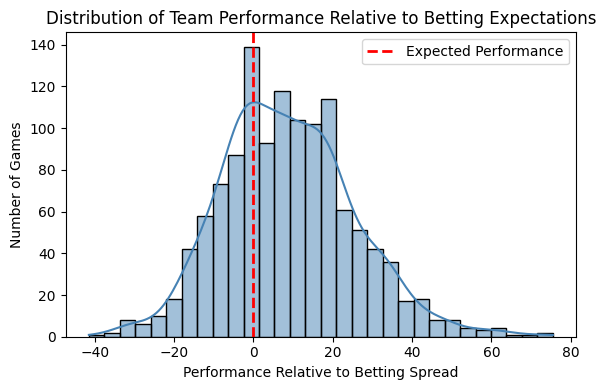

In [51]:

plt.figure(figsize=(6,4))

sns.histplot(
    df_merged["performance"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Expected Performance"
)

plt.title("Distribution of Team Performance Relative to Betting Expectations")
plt.xlabel("Performance Relative to Betting Spread")
plt.ylabel("Number of Games")
plt.legend()

plt.tight_layout()
plt.show()

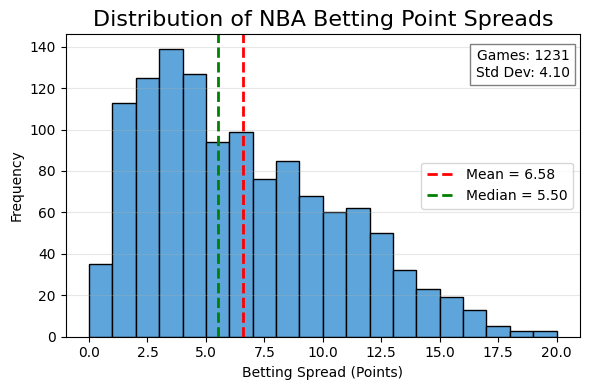

In [15]:
spread = df_merged["spread"]

plt.figure(figsize=(6,4))

plt.hist(
    spread,
    bins=np.arange(spread.min()-0.5, spread.max()+1.5, 1),
    color="#5DA5DA",
    edgecolor="black"
)

plt.axvline(spread.mean(), color="red", linestyle="--",
            linewidth=2, label=f"Mean = {spread.mean():.2f}")

plt.axvline(spread.median(), color="green", linestyle="--",
            linewidth=2, label=f"Median = {spread.median():.2f}")

plt.text(
    0.98, 0.95,
    f"Games: {len(spread)}\nStd Dev: {spread.std():.2f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", edgecolor="gray")
)

plt.title("Distribution of NBA Betting Point Spreads", fontsize=16)
plt.xlabel("Betting Spread (Points)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

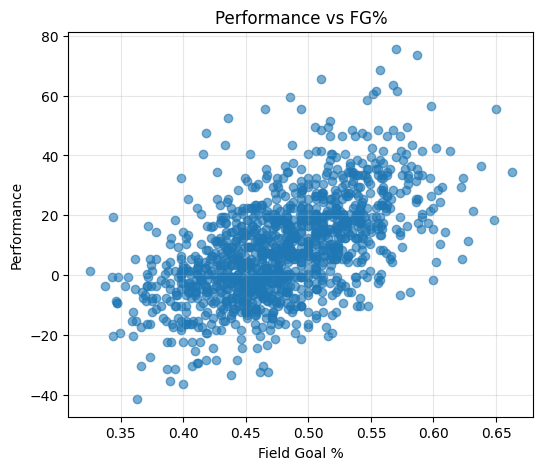

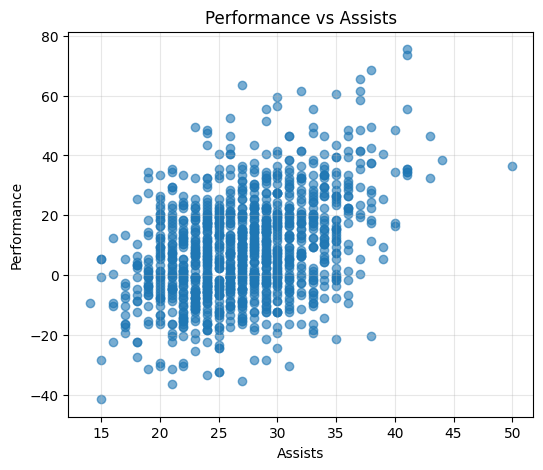

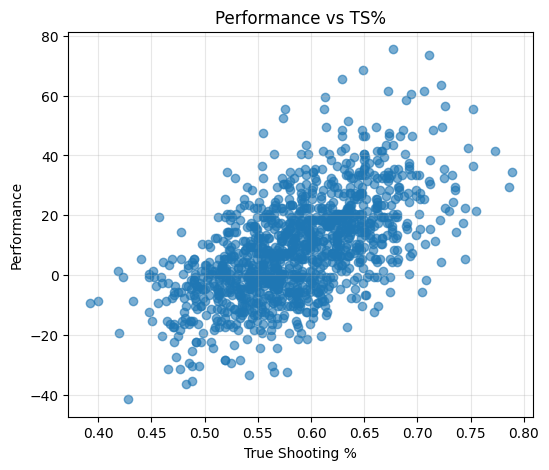

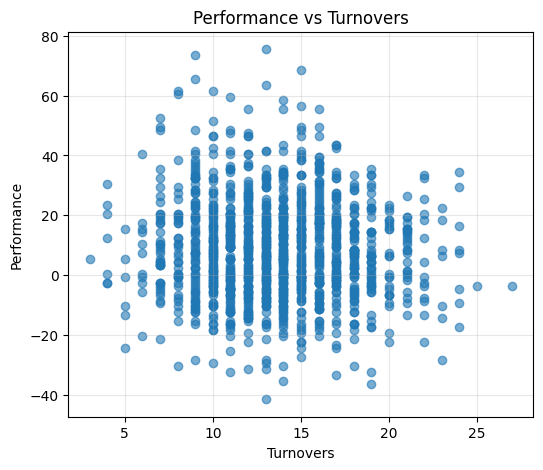

In [16]:
# Performance vs FG%
plt.figure(figsize=(6,5))
plt.scatter(df_merged['home_fg_pct'], df_merged['performance'], alpha=0.6)
plt.xlabel('Field Goal %')
plt.ylabel('Performance')
plt.title('Performance vs FG%')
plt.grid(alpha=0.3)
plt.show()

# Performance vs Assists
plt.figure(figsize=(6,5))
plt.scatter(df_merged['home_ast'], df_merged['performance'], alpha=0.6)
plt.xlabel('Assists')
plt.ylabel('Performance')
plt.title('Performance vs Assists')
plt.grid(alpha=0.3)
plt.show()

# Performance vs True Shooting %
plt.figure(figsize=(6,5))
plt.scatter(df_merged['home_ts_pct'], df_merged['performance'], alpha=0.6)
plt.xlabel('True Shooting %')
plt.ylabel('Performance')
plt.title('Performance vs TS%')
plt.grid(alpha=0.3)
plt.show()

# Performance vs Turnovers
plt.figure(figsize=(6,5))
plt.scatter(df_merged['home_tov'], df_merged['performance'], alpha=0.6)
plt.xlabel('Turnovers')
plt.ylabel('Performance')
plt.title('Performance vs Turnovers')
plt.grid(alpha=0.3)
plt.show()

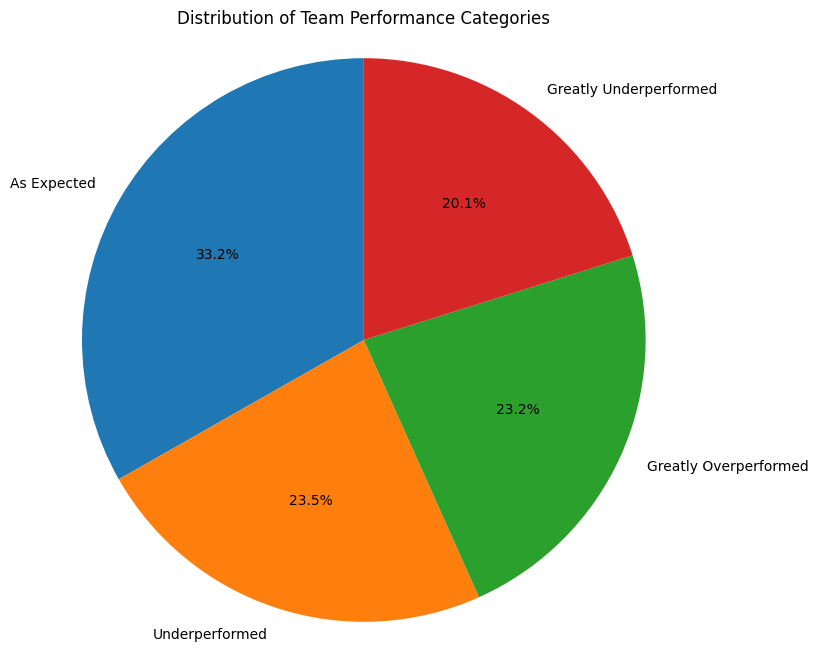

In [17]:
# Count each category
category_counts = df_merged["performance_category"].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Team Performance Categories")
plt.axis("equal")  # Makes the pie chart circular
plt.show()

In [18]:
# Determine the winner
df_merged["winner"] = np.where(
    df_merged["score_home"] > df_merged["score_away"],
    "home",
    "away"
)

# Create upset indicator
df_merged["upset"] = df_merged["winner"] != df_merged["whos_favored"]

# Optional descriptive label
df_merged["upset_label"] = np.where(
    df_merged["upset"],
    "Upset",
    "Expected Result"
)

In [19]:
df_merged["upset_label"] = np.where(df_merged["upset"], "Upset", "Expected Result")

df_merged["upset_label"].value_counts()

df_merged["upset"].mean()

df_merged.describe().T

,count,mean,min,25%,50%,75%,max,std
season,1231.0,2024.0,2024.0,2024.0,2024.0,2024.0,2024.0,0.0
date,1231,2024-01-19 13:30:39.480097536,2023-10-24 00:00:00,2023-12-07 12:00:00,2024-01-19 00:00:00,2024-03-05 12:00:00,2024-04-14 00:00:00,NaN
score_away,1231.0,113.13485,74.0,104.0,113.0,122.0,157.0,12.745782
score_home,1231.0,115.29082,73.0,106.0,114.0,124.0,157.0,12.853138
q1_away,1231.0,28.12104,11.0,24.0,28.0,32.0,47.0,6.045556
...,...,...,...,...,...,...,...,...
away_opp_off_rtg,1231.0,116.402843,78.4,108.55,116.1,124.3,150.2,11.557072
away_opp_def_rtg,1231.0,114.29472,74.4,106.2,114.5,122.5,156.7,12.20291
away_Win,1231.0,0.456539,0.0,0.0,0.0,1.0,1.0,0.49831
actual_margin,1231.0,2.155971,-53.0,-9.0,2.0,12.0,62.0,15.639435


<Axes: >

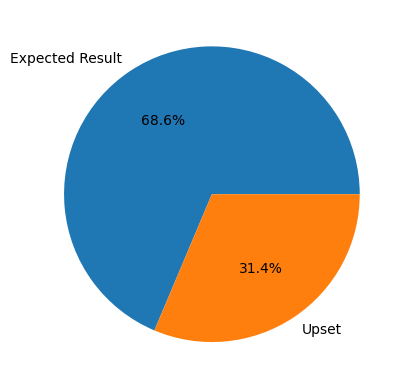

In [20]:
df_merged["upset_label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ylabel=""
)

Text(0, 0.5, 'Games')

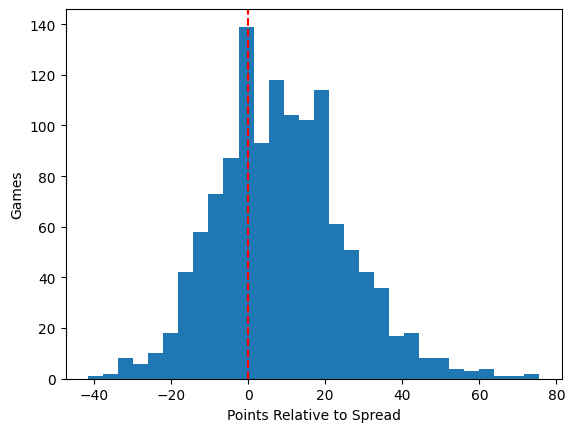

In [21]:
plt.hist(df_merged["performance"], bins=30)

plt.axvline(0, color="red", linestyle="--")

plt.xlabel("Points Relative to Spread")
plt.ylabel("Games")

<Axes: xlabel='upset', ylabel='home_fg_pct'>

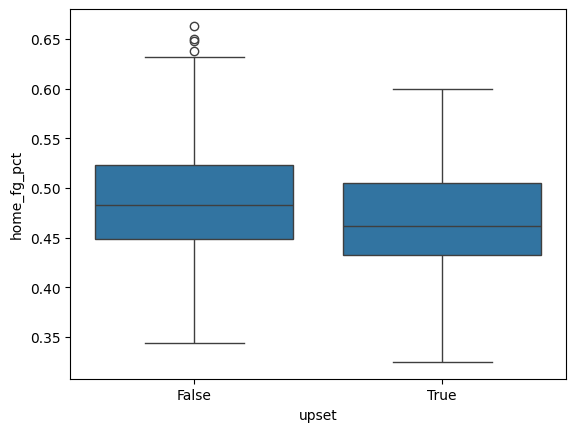

In [22]:
sns.boxplot(
    data=df_merged,
    x="upset",
    y="home_fg_pct"
)

<Axes: xlabel='home_fg_pct', ylabel='performance'>

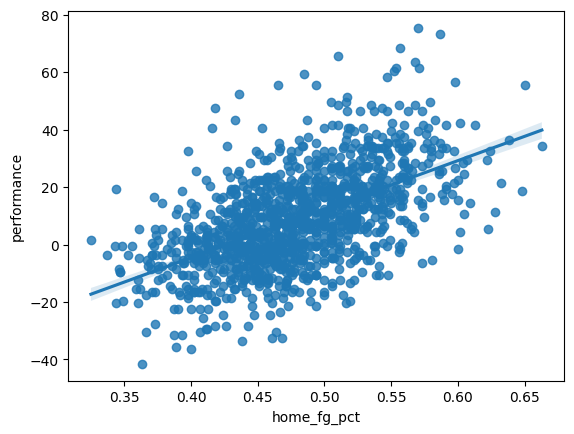

In [23]:
sns.regplot(
    data=df_merged,
    x="home_fg_pct",
    y="performance"
)

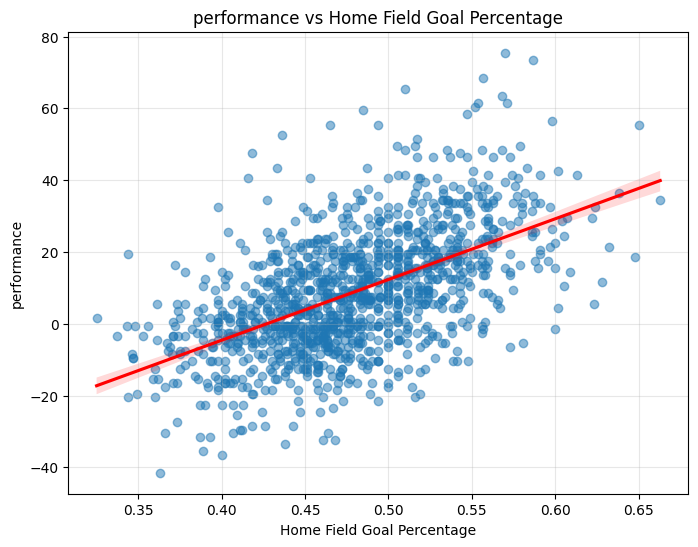

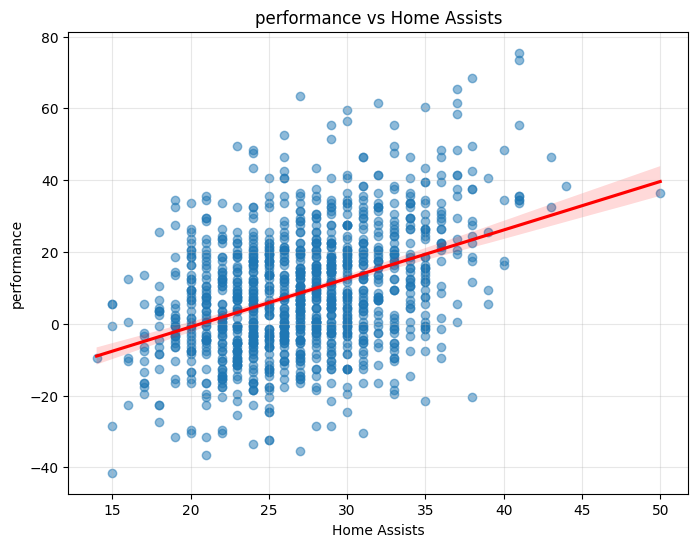

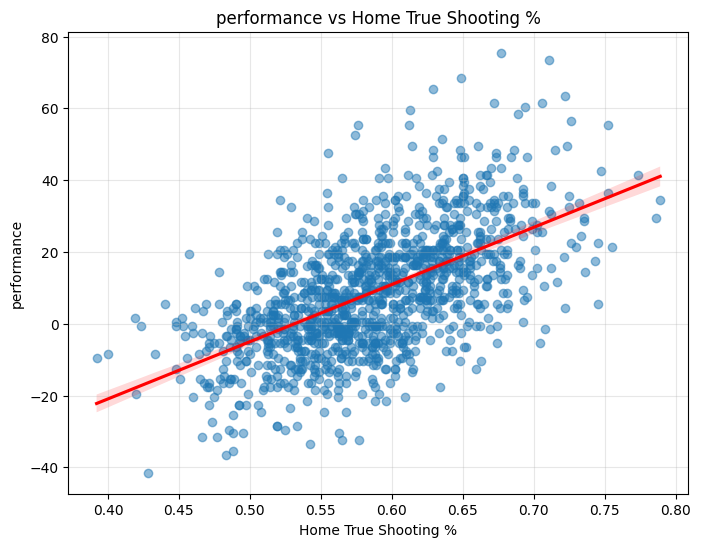

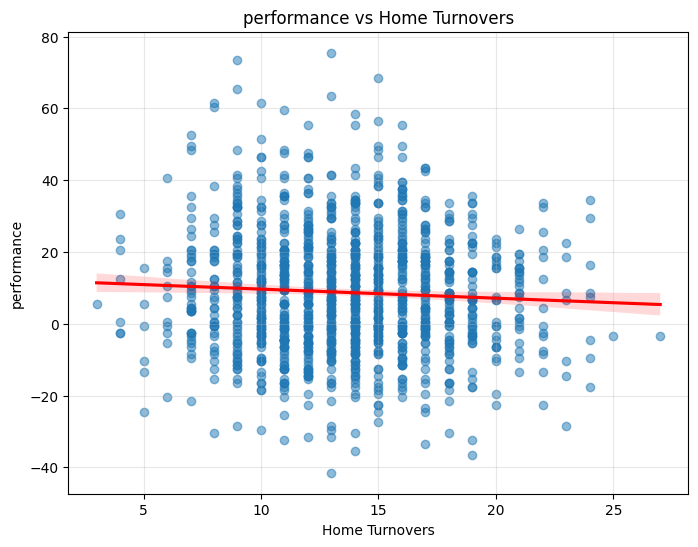

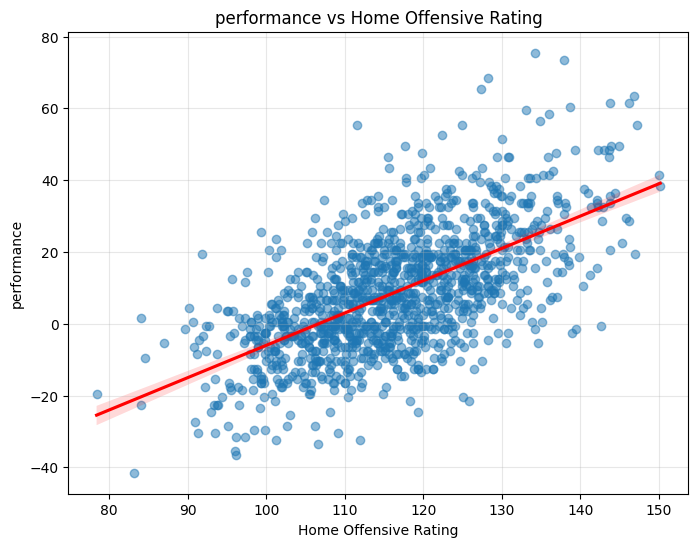

In [24]:
#Overperformance vs. Field Goal Percentage
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="home_fg_pct",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Home Field Goal Percentage")
plt.xlabel("Home Field Goal Percentage")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="home_ast",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
#2. performance vs. Assists
plt.title("performance vs Home Assists")
plt.xlabel("Home Assists")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,6))
#performance vs. True Shooting %
sns.regplot(
    data=df_merged,
    x="home_ts_pct",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Home True Shooting %")
plt.xlabel("Home True Shooting %")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()
#performance vs. Turnovers
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="home_tov",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Home Turnovers")
plt.xlabel("Home Turnovers")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()
#performance vs. Offensive Rating
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="home_off_rtg",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Home Offensive Rating")
plt.xlabel("Home Offensive Rating")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()

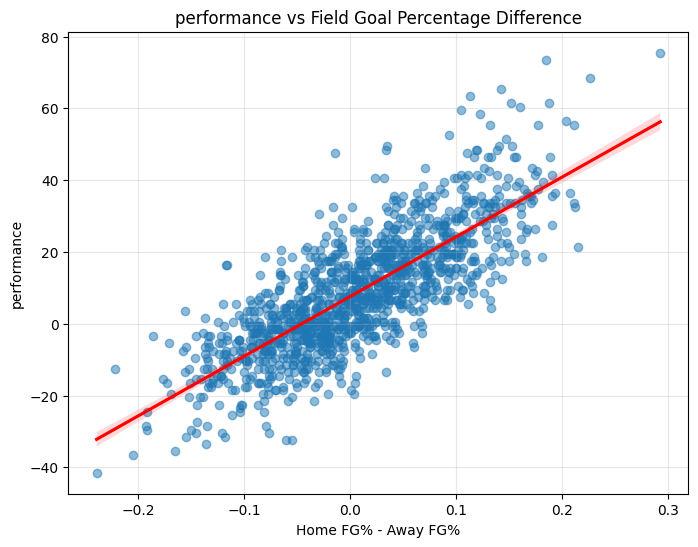

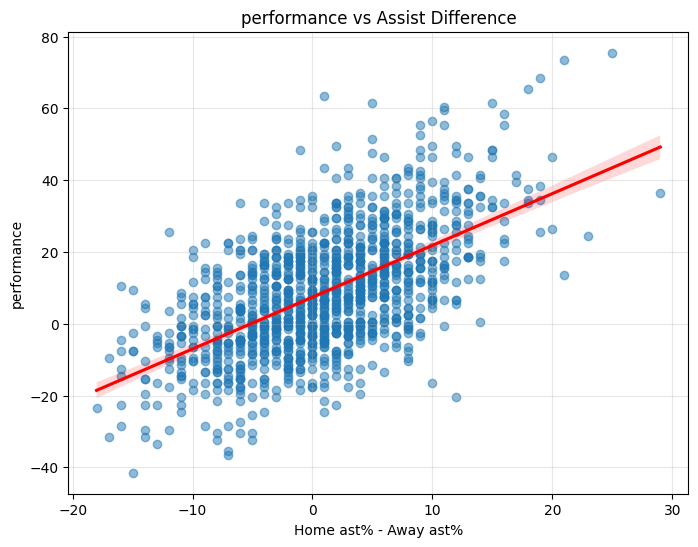

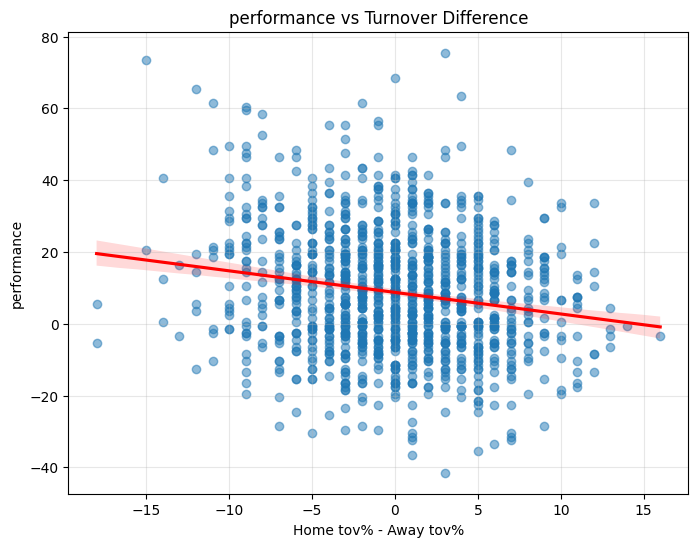

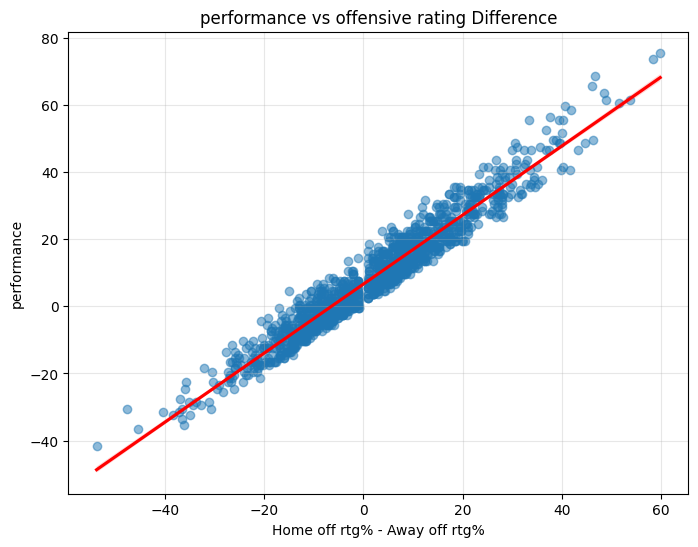

In [ ]:

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="fg_pct_diff",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Field Goal Percentage Difference")
plt.xlabel("Home FG% - Away FG%")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="ast_diff",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Assist Difference")
plt.xlabel("Home ast% - Away ast%")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="tov_diff",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs Turnover Difference")
plt.xlabel("Home tov% - Away tov%")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_merged,
    x="off_rtg_diff",
    y="performance",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("performance vs offensive rating Difference")
plt.xlabel("Home off rtg% - Away off rtg%")
plt.ylabel("performance")
plt.grid(alpha=0.3)

plt.show()

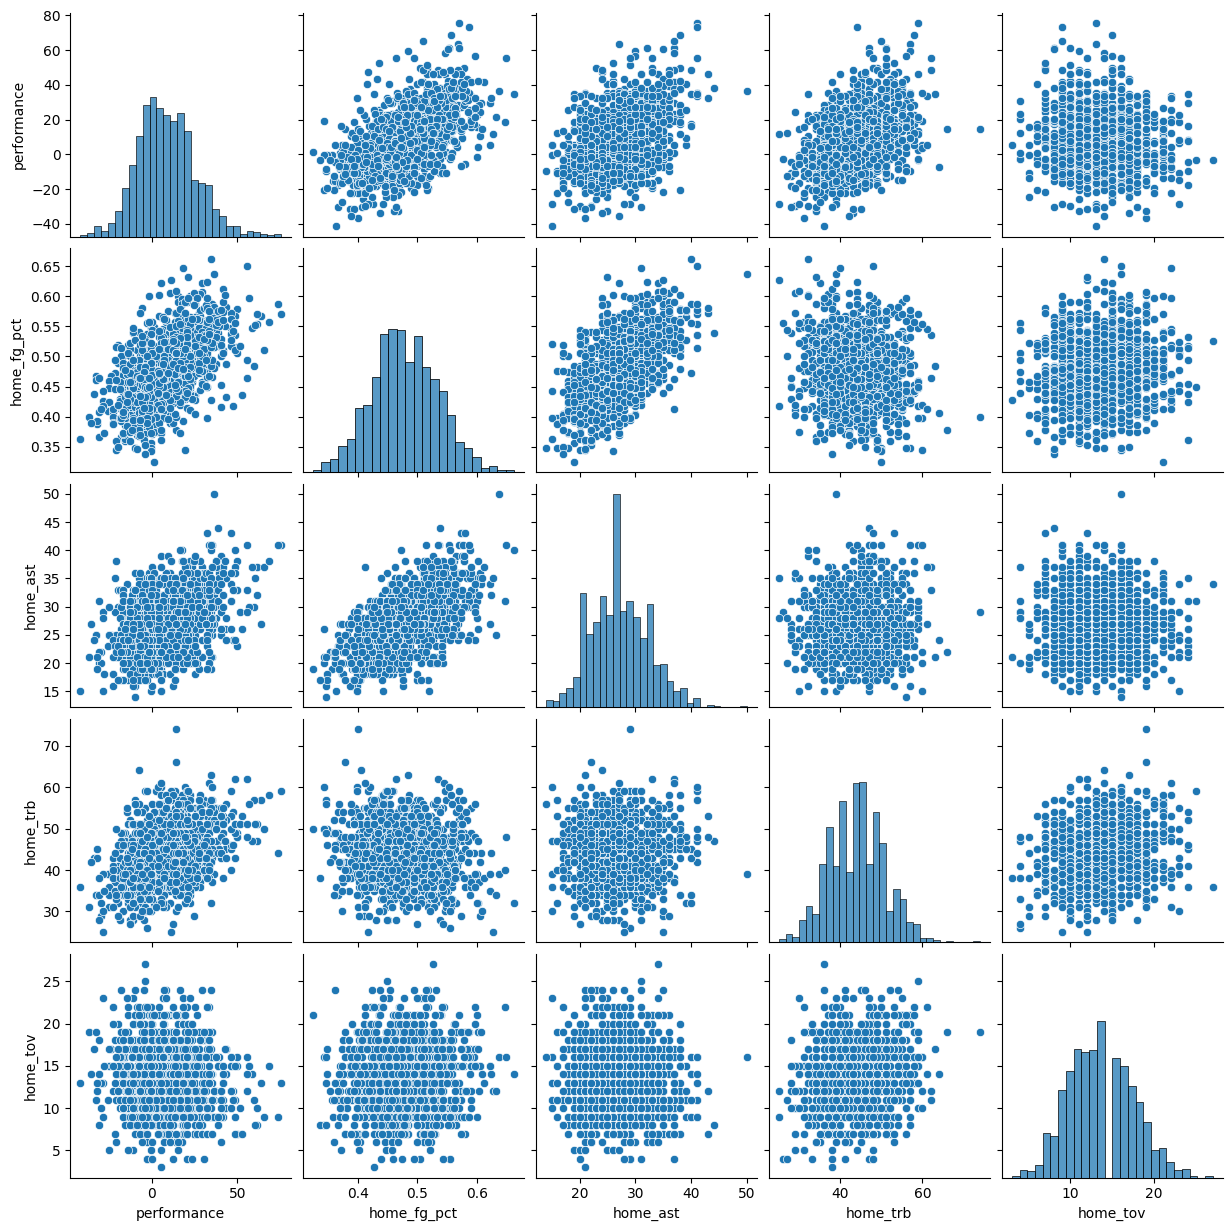

In [26]:
sns.pairplot(
    df_merged[
        [
            "performance",
            "home_fg_pct",
            "home_ast",
            "home_trb",
            "home_tov"
        ]
    ]
)

In [33]:
corr_vars = [
    "performance",
    "fg_pct_diff",
    "ast_diff",
    "trb_diff",
    "tov_diff",
    "off_rtg_diff",
    "def_rtg_diff",
    "ts_pct_diff",
    "efg_pct_diff"
]

# Calculate correlations
corr_matrix = df_merged[corr_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Team Performance Metrics")
plt.tight_layout()
plt.show()

KeyError: "['trb_diff', 'def_rtg_diff', 'ts_pct_diff', 'efg_pct_diff'] not in index"

8. Feature Importance (if you build a model) ⭐⭐⭐

If you train a Random Forest to predict overperformance or upsets, plot the feature importances.

Example:

FG%                ███████████████

Off Rating         ████████████

Turnovers          █████████

Rebounds           ███████

Assists            █████

Blocks             ████

This often becomes the most impactful figure in the report because it directly answers:

Which metrics matter the most?